# Trabajo Práctico 2: Visión por Computadora I

**Carrera de Especialización en Inteligencia Artificial, FIUBA**

#### **Alumno 1:** Lorenzo Fioranelli, Rocío Macarena - a2643
#### **Alumno 2:** Lerner, Federico Ezequiel - a2619
#### **Alumno 3:** Makk, Azul de los Angeles - a2622
#### **Alumno 4:** Moguilner Reh, Nicolás Francisco - a2623

---

**Objetivo:** implementar un detector de máximo enfoque sobre el video `Material_TPs/TP2/focus_video.mov`, usando análisis espectral de forma parecida a lo que hace el autofoco por contraste de una cámara digital.

El enunciado pide:

1. Implementar la métrica de *"Image Sharpness Measure for Blurred Images in Frequency Domain"* (De y Masilamani, 2013), que llamaremos **FM**, y usarla en dos experimentos:
   - **Experimento 1:** medición sobre todo el frame.
   - **Experimento 2:** medición sobre una ROI centrada, con área igual al 5 % o al 10 % del frame.
2. Para cada experimento, mostrar la evolución de la métrica frame a frame y **detectar automáticamente** el punto de máximo enfoque.
3. Medir sobre una **matriz de enfoque** de $N \times M$ elementos superpuesta al frame, como en la figura del enunciado.
4. **Puntos extra:** aplicar *unsharp masking* para expandir la zona de enfoque.

## Preparación

El video está en `Material_TPs/TP2` dentro de este mismo repo, así que lo leemos con una ruta relativa a la raíz del repo, que es donde está el notebook.

In [1]:
from pathlib import Path

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

plt.rcParams['figure.dpi'] = 90

# El material está en este mismo repo, junto al notebook.
RUTA = Path('Material_TPs') / 'TP2'
RUTA_VIDEO = RUTA / 'focus_video.mov'
assert RUTA_VIDEO.is_file(), f'No se encontró {RUTA_VIDEO.resolve()}: correr el notebook desde la raíz del repo.'

print('OpenCV', cv.__version__, '| NumPy', np.__version__)
print('Video:', RUTA_VIDEO.resolve())

OpenCV 5.0.0 | NumPy 2.4.6
Video: /Users/federicolerner/Documents/CEIA/3B/VpCI/CEIA-3B-VpC1/Material_TPs/TP2/focus_video.mov


In [2]:
def mostrar(img, titulo='', ax=None):
    # Muestra una imagen BGR (OpenCV) o de un solo canal con matplotlib.
    if ax is None:
        _, ax = plt.subplots()
    if img.ndim == 2:
        ax.imshow(img, cmap='gray', vmin=0, vmax=255)
    else:
        ax.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
    ax.set_title(titulo, fontsize=9)
    ax.axis('off')
    return ax

### Lectura del video

Leemos el video completo a memoria con un bucle de `VideoCapture.read()`. Es chico, así que lo podemos procesar varias veces sin volver a decodificarlo. Guardamos cada frame en color, para dibujar encima, y en escala de grises, porque la métrica trabaja sobre la intensidad.

In [3]:
captura = cv.VideoCapture(str(RUTA_VIDEO))
assert captura.isOpened(), f'No se pudo abrir {RUTA_VIDEO}'
FPS = captura.get(cv.CAP_PROP_FPS)

frames_bgr = []
while True:
    ok, frame = captura.read()
    if not ok:
        break
    frames_bgr.append(frame)
captura.release()

frames = [cv.cvtColor(f, cv.COLOR_BGR2GRAY) for f in frames_bgr]
N_FRAMES = len(frames)
ALTO, ANCHO = frames[0].shape

print(f'{N_FRAMES} frames de {ANCHO}x{ALTO} px a {FPS:.2f} fps ({N_FRAMES / FPS:.1f} s)')

171 frames de 640x360 px a 29.97 fps (5.7 s)


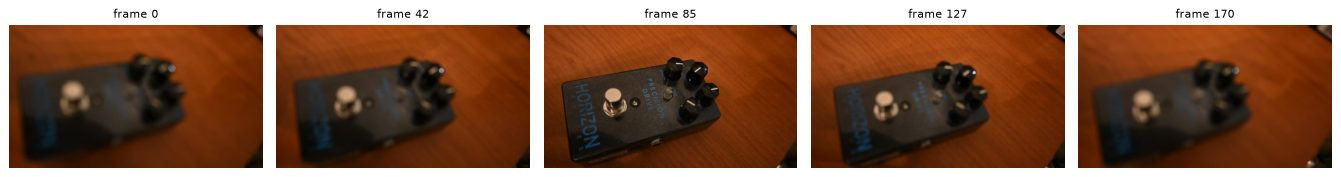

In [4]:
muestras = np.linspace(0, N_FRAMES - 1, 5).astype(int)
fig, axes = plt.subplots(1, len(muestras), figsize=(15, 2.2))
for ax, i in zip(axes, muestras):
    mostrar(frames_bgr[i], f'frame {i}', ax)
fig.tight_layout()
plt.show()

El video es un barrido de foco sobre una escena fija: un pedal de guitarra apoyado sobre una mesa y fotografiado en diagonal. Arranca muy desenfocado, pasa por un tramo nítido a mitad de camino y vuelve a desenfocarse. Como la cámara no se mueve y sólo cambia el foco, la variación de la métrica entre frames se debe casi por completo al desenfoque.

---
# 1. La métrica FM (dominio de la frecuencia)

## 1.1 La idea

Un desenfoque óptico se modela bien como la convolución de la imagen con un núcleo pasabajos, que en primera aproximación es gaussiano, y por el teorema de convolución eso equivale a multiplicar su espectro por el de un filtro pasabajos. En la práctica, cuanto más desenfocada está la imagen, menos componentes de alta frecuencia con energía significativa quedan en su espectro. El paper mide exactamente eso.

Dada una imagen $I$ de $M \times N$:

1. $F = \mathcal{F}\{I\}$, la FFT 2D de la imagen.
2. $F_c$ = $F$ con el origen desplazado al centro (`fftshift`).
3. $AF = |F_c|$.
4. $M_{AF} = \max(AF)$.
5. $T_H$ = cantidad de componentes de $F$ con $AF > M_{AF}/1000$.
6. La medida es la **fracción** de componentes que superan el umbral:

$$FM = \frac{T_H}{M \cdot N}$$

Dos cosas para notar. En imágenes de intensidad no negativa como éstas, el máximo del espectro es la componente continua $F(0,0) = \sum I(x,y)$, así que el umbral queda relativo al brillo total de la imagen y **FM no cambia si multiplicamos la imagen por una constante**. Eso nos conviene porque la exposición varía un poco a lo largo del video, aunque la invariancia es exacta sólo para un cambio de ganancia puro: si además se recortan valores en 255, aparece ruido o cambia un offset, la métrica sí se mueve. La otra: el centrado del paso 2 no cambia el conteo, sólo permuta las componentes, pero lo dejamos porque después nos sirve para mostrar el espectro.

## 1.2 Implementación

In [5]:
def espectro_centrado(img):
    # Módulo de la FFT 2D con la frecuencia cero en el centro (pasos 1 a 3 del paper).
    return np.abs(np.fft.fftshift(np.fft.fft2(img.astype(np.float64))))


def medida_fm(img, divisor=1000):
    # Image Sharpness Measure (De & Masilamani, 2013): fracción de componentes del espectro
    # cuyo módulo supera max(|F|) / divisor.
    af = espectro_centrado(img)
    umbral = af.max() / divisor
    return np.count_nonzero(af > umbral) / img.size

Para ver qué está contando la métrica, reproducimos la idea de la Fig. 3 del paper y mostramos el espectro centrado (en escala logarítmica) y la máscara de componentes que superan el umbral para un frame desenfocado y para uno nítido.

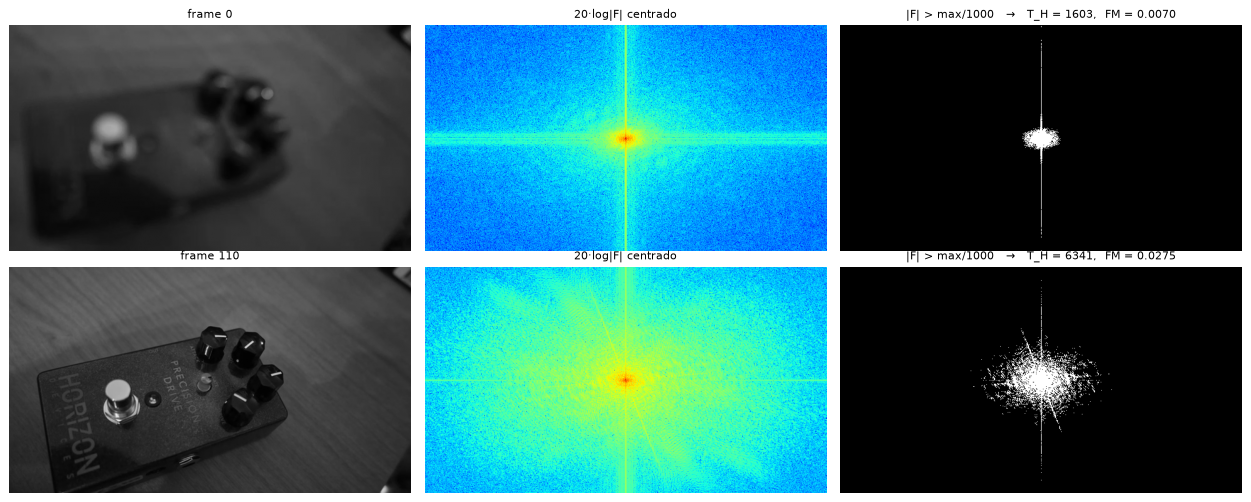

In [6]:
def mascara_fm(img, divisor=1000):
    af = espectro_centrado(img)
    return af > af.max() / divisor


fig, axes = plt.subplots(2, 3, figsize=(14, 5.6))
for fila, i in enumerate((0, 110)):
    af = espectro_centrado(frames[i])
    mascara = mascara_fm(frames[i])
    mostrar(frames[i], f'frame {i}', axes[fila, 0])
    axes[fila, 1].imshow(20 * np.log(af + 1), cmap='jet')
    axes[fila, 1].set_title('20·log|F| centrado', fontsize=9)
    axes[fila, 1].axis('off')
    axes[fila, 2].imshow(mascara, cmap='gray')
    axes[fila, 2].set_title(f'|F| > max/1000   →   T_H = {mascara.sum()},  FM = {mascara.mean():.4f}',
                            fontsize=9)
    axes[fila, 2].axis('off')
fig.tight_layout()
plt.show()

En el frame desenfocado las componentes que superan el umbral se concentran alrededor del centro, es decir, en las bajas frecuencias. En el nítido la máscara se extiende hacia todo el plano de frecuencias y el conteo se multiplica por cuatro. También se ven la cruz horizontal y la vertical que pasan por el origen. No son contenido de la escena: aparecen porque la FFT asume que la imagen es periódica, y los saltos entre bordes opuestos del frame introducen componentes a lo largo de los ejes. Parecen aportar una base casi constante a la cuenta: en este video no impidieron ubicar bien el máximo, pero sí reducen el rango dinámico de la métrica. Vamos a volver sobre esto con las ROI.

## 1.3 Verificación controlada

Antes de usarla sobre el video, repetimos el experimento de la Fig. 5a del paper. Tomamos un frame nítido, lo desenfocamos con gaussianas de $\sigma$ creciente y verificamos que la métrica decrezca monótonamente.

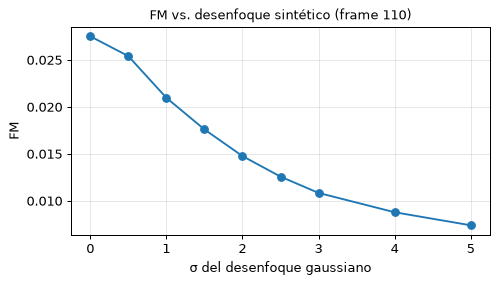

¿Monótonamente decreciente? True


In [7]:
sigmas = [0, 0.5, 1, 1.5, 2, 2.5, 3, 4, 5]
nitido = frames[110]
fm_sigma = [medida_fm(nitido if s == 0 else cv.GaussianBlur(nitido, (0, 0), s)) for s in sigmas]

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(sigmas, fm_sigma, 'o-')
ax.set_xlabel('σ del desenfoque gaussiano')
ax.set_ylabel('FM')
ax.set_title('FM vs. desenfoque sintético (frame 110)', fontsize=10)
ax.grid(alpha=0.3)
plt.show()

print('¿Monótonamente decreciente?', bool(np.all(np.diff(fm_sigma) < 0)))

Se comporta como en el paper: cada aumento de $\sigma$ baja la métrica, sin la no monotonía que el paper les atribuye a CPBD y JNB. Esta es la propiedad que necesitamos para buscar un máximo.

## 1.4 Detector automático de máximo enfoque

El detector recibe la curva de la métrica frame a frame y devuelve:

- **el frame de máximo enfoque**, como el argumento del máximo;
- **la zona de enfoque**, el intervalo contiguo de frames alrededor del máximo en el que la curva se mantiene por encima de una fracción `tolerancia` de su rango. Con 0.9, la zona son los frames que están dentro del 10 % superior entre el peor y el mejor valor observado.

Por la compresión del video y el ruido del sensor, la curva tiene ruido de frame a frame. Para que un pico espurio no defina el máximo, la suavizamos antes con una media móvil de 5 frames (1/6 de segundo). Es un filtro de caja aplicado en 1D sobre el eje temporal.

In [8]:
def suavizar(curva, ventana=5):
    # Media móvil centrada; replica los bordes para no perder frames.
    curva = np.asarray(curva, dtype=np.float64)
    if ventana <= 1:
        return curva
    assert ventana % 2 == 1, 'la ventana tiene que ser impar para conservar la longitud de la curva'
    extendida = np.pad(curva, ventana // 2, mode='edge')
    return np.convolve(extendida, np.ones(ventana) / ventana, mode='valid')


def intervalo_alrededor(mascara, centro):
    # Extremos del tramo contiguo de True que contiene a 'centro'.
    inicio = fin = centro
    while inicio > 0 and mascara[inicio - 1]:
        inicio -= 1
    while fin < len(mascara) - 1 and mascara[fin + 1]:
        fin += 1
    return inicio, fin


def detectar_maximo_enfoque(curva, ventana=5, tolerancia=0.9, umbral=None):
    # Devuelve el frame de máximo enfoque y la zona de enfoque que lo rodea.
    # Si no se pasa un umbral absoluto, se usa min + tolerancia * (max - min) de la curva suavizada.
    s = suavizar(curva, ventana)
    frame_max = int(np.argmax(s))
    if umbral is None:
        umbral = s.min() + tolerancia * (s.max() - s.min())
    inicio, fin = intervalo_alrededor(s >= umbral, frame_max)
    return {'frame_max': frame_max, 'inicio': inicio, 'fin': fin, 'umbral': float(umbral), 'suavizada': s}


def medir_video(frames, region=None, metrica=medida_fm):
    # Aplica la métrica a cada frame, opcionalmente sólo dentro de region = (x, y, ancho, alto).
    if region is None:
        return np.array([metrica(f) for f in frames])
    x, y, w, h = region
    return np.array([metrica(f[y:y + h, x:x + w]) for f in frames])


def graficar_curva(ax, curva, det, titulo='', color='C0', etiqueta='FM'):
    ax.plot(curva, '.', color=color, alpha=0.45, markersize=5, label=f'{etiqueta} por frame')
    ax.plot(det['suavizada'], '-', color=color, linewidth=1.8, label=f'{etiqueta} suavizada')
    ax.axvspan(det['inicio'], det['fin'], color=color, alpha=0.12,
               label=f"zona de enfoque [{det['inicio']}, {det['fin']}]")
    ax.axvline(det['frame_max'], color='k', linestyle='--', linewidth=1,
               label=f"máximo: frame {det['frame_max']}")
    ax.set_xlabel('Frame #')
    ax.set_ylabel(etiqueta)
    ax.set_title(titulo, fontsize=10)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

---
# 2. Experimento 1: medición sobre todo el frame

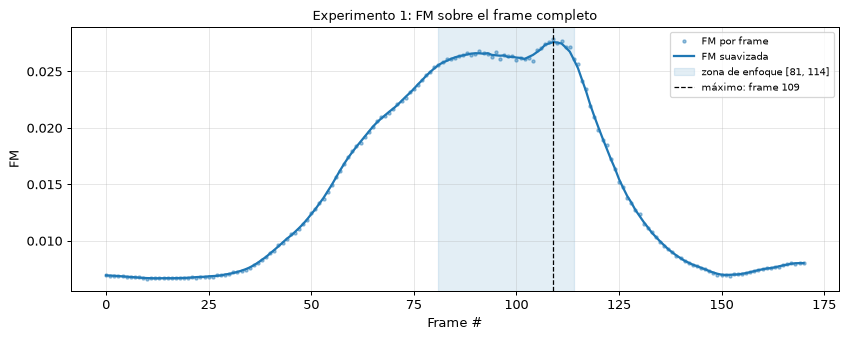

Frame de máximo enfoque : 109  (t = 3.64 s),  FM = 0.0278
Zona de enfoque         : frames 81 a 114 (34 frames)
Máximo sin suavizar     : frame 109
Rango dinámico max/min  : 4.19


In [9]:
curva_frame = medir_video(frames)
det_frame = detectar_maximo_enfoque(curva_frame)

fig, ax = plt.subplots(figsize=(11, 3.8))
graficar_curva(ax, curva_frame, det_frame, 'Experimento 1: FM sobre el frame completo')
plt.show()

f_max = det_frame['frame_max']
print(f"Frame de máximo enfoque : {f_max}  (t = {f_max / FPS:.2f} s),  FM = {curva_frame[f_max]:.4f}")
print(f"Zona de enfoque         : frames {det_frame['inicio']} a {det_frame['fin']} "
      f"({det_frame['fin'] - det_frame['inicio'] + 1} frames)")
print(f"Máximo sin suavizar     : frame {int(np.argmax(curva_frame))}")
print(f"Rango dinámico max/min  : {curva_frame.max() / curva_frame.min():.2f}")

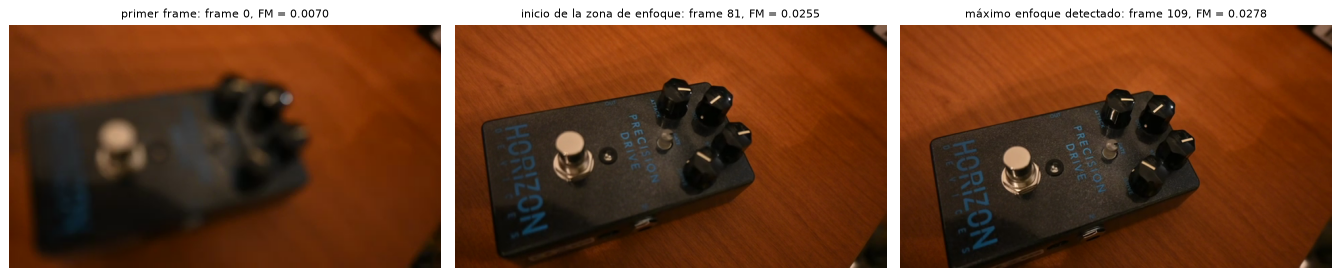

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3))
for ax, i, rotulo in zip(axes, (0, det_frame['inicio'], f_max),
                         ('primer frame', 'inicio de la zona de enfoque', 'máximo enfoque detectado')):
    mostrar(frames_bgr[i], f'{rotulo}: frame {i}, FM = {curva_frame[i]:.4f}', ax)
fig.tight_layout()
plt.show()

La curva tiene la forma que se espera en un barrido de foco: plana y baja mientras la imagen está muy desenfocada, una subida pronunciada cuando el plano de foco empieza a atravesar la escena, un máximo y una caída del otro lado. El detector ubica el máximo en el **frame 109**. Coincide con el frame donde se leen nítidos los textos del pedal y las marcas de las perillas.

La curva sobre el frame completo tiene dos limitaciones. La primera es que el pico es **ancho**: la zona de enfoque detectada abarca 34 frames (del 81 al 114), más de un segundo de video. Cuando el plano de foco pasa por el pedal, otras partes de la mesa se desenfocan, y ambas cosas se compensan en la medición global. La segunda es que el rango dinámico es chico: el mejor frame tiene apenas unas 4 veces más componentes que el peor. Buena parte del frame es la mesa, que tiene poca textura, y sus componentes de frecuencia apenas cambian con el foco.

---
# 3. Experimento 2: ROI central

Una cámara que enfoca "al centro" mide sólo sobre una región chica en el medio del cuadro. Definimos una ROI centrada con la misma relación de aspecto que el frame, con lados escalados por $\sqrt{a}$ para que su área sea una fracción $a$ del total. Probamos con $a = 5\%$ y $a = 10\%$.

In [11]:
def roi_central(alto, ancho, fraccion_area):
    # (x, y, w, h) de una ROI centrada con el aspecto del frame y área = fraccion_area del total.
    escala = np.sqrt(fraccion_area)
    h, w = int(round(alto * escala)), int(round(ancho * escala))
    return (ancho - w) // 2, (alto - h) // 2, w, h


ROIS = {'ROI 5 %': roi_central(ALTO, ANCHO, 0.05),
        'ROI 10 %': roi_central(ALTO, ANCHO, 0.10)}

curvas_roi, dets_roi = {}, {}
for nombre, roi in ROIS.items():
    x, y, w, h = roi
    curvas_roi[nombre] = medir_video(frames, roi)
    dets_roi[nombre] = detectar_maximo_enfoque(curvas_roi[nombre])
    d = dets_roi[nombre]
    print(f"{nombre:9s} {w}x{h} px ({100 * w * h / (ANCHO * ALTO):.1f} % del área)  →  "
          f"máximo en frame {d['frame_max']},  zona [{d['inicio']}, {d['fin']}] "
          f"({d['fin'] - d['inicio'] + 1} frames),  max/min = "
          f"{curvas_roi[nombre].max() / curvas_roi[nombre].min():.2f}")

ROI 5 %   143x80 px (5.0 % del área)  →  máximo en frame 111,  zona [97, 113] (17 frames),  max/min = 8.41


ROI 10 %  202x114 px (10.0 % del área)  →  máximo en frame 111,  zona [101, 113] (13 frames),  max/min = 8.33


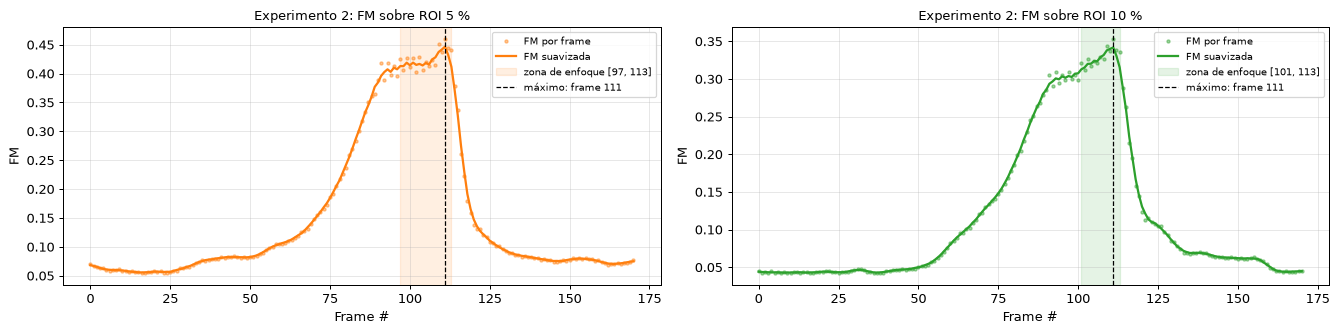

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 3.8))
for ax, (nombre, color) in zip(axes, (('ROI 5 %', 'C1'), ('ROI 10 %', 'C2'))):
    graficar_curva(ax, curvas_roi[nombre], dets_roi[nombre], f'Experimento 2: FM sobre {nombre}', color)
fig.tight_layout()
plt.show()

Los valores absolutos de FM no son comparables entre regiones de distinto tamaño, aunque FM esté dividida por la cantidad de píxeles. Una parte de la diferencia viene del umbral: es la componente continua dividida por 1000, y la continua crece en proporción al área. Las componentes del ruido y de las texturas sin una estructura marcada crecen más despacio, así que en una región chica quedan más cerca del umbral y lo superan en mayor proporción. No es una regla general: un borde largo o una textura periódica sí pueden crecer al mismo ritmo que la continua. También influyen el contenido distinto de cada región, el muestreo de frecuencias, que depende del tamaño, y las discontinuidades que introduce el borde del recorte. Para comparar la **forma** de las tres curvas, las normalizamos al intervalo $[0, 1]$.

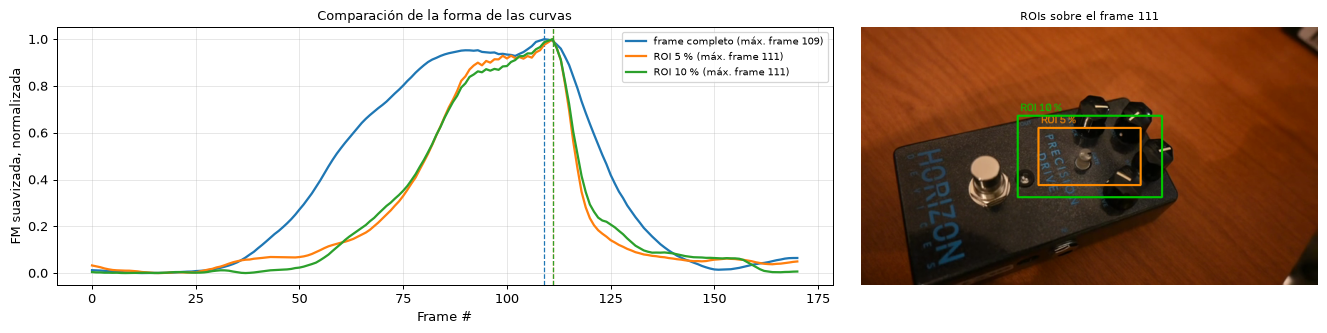

In [13]:
def normalizar(c):
    return (c - c.min()) / (c.max() - c.min())


fig, (ax, ax_img) = plt.subplots(1, 2, figsize=(15, 3.8), gridspec_kw={'width_ratios': [1.6, 1]})
for (nombre, curva, det), color in zip(
        [('frame completo', curva_frame, det_frame)] +
        [(n, curvas_roi[n], dets_roi[n]) for n in ROIS], ('C0', 'C1', 'C2')):
    ax.plot(normalizar(det['suavizada']), color=color, linewidth=1.8,
            label=f"{nombre} (máx. frame {det['frame_max']})")
    ax.axvline(det['frame_max'], color=color, linestyle='--', linewidth=1)
ax.set_xlabel('Frame #')
ax.set_ylabel('FM suavizada, normalizada')
ax.set_title('Comparación de la forma de las curvas', fontsize=10)
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

vista = frames_bgr[dets_roi['ROI 10 %']['frame_max']].copy()
for (nombre, (x, y, w, h)), color in zip(ROIS.items(), ((0, 140, 255), (0, 200, 0))):
    cv.rectangle(vista, (x, y), (x + w, y + h), color, 2)
    cv.putText(vista, nombre, (x + 4, y - 6), cv.FONT_HERSHEY_SIMPLEX, 0.5, color, 1, cv.LINE_AA)
mostrar(vista, f"ROIs sobre el frame {dets_roi['ROI 10 %']['frame_max']}", ax_img)
fig.tight_layout()
plt.show()

Las dos ROI detectan el máximo en el **frame 111**, dos frames después que el frame completo, y el resultado es claramente mejor:

- **El pico es mucho más angosto.** La zona de enfoque pasa de 34 frames a 17 con la ROI de 5 % y a 13 con la de 10 %. La ROI cae sobre el pedal, que está a una distancia bastante uniforme de la cámara, así que no hay regiones que se enfoquen mientras otras se desenfocan.
- **El contraste de la curva es mucho mayor.** El cociente máx/mín pasa de ~4 en el frame completo a ~8 en las ROI. La región está dominada por bordes nítidos (textos, perillas, el LED), que son justamente las componentes que el desenfoque elimina.
- La ROI de 5 % y la de 10 % dan prácticamente la misma respuesta. La de 5 % tiene un contraste ligeramente mayor, porque tiene proporcionalmente menos mesa, pero es más ruidosa frame a frame porque estima el espectro con menos píxeles, y ese ruido ensancha su zona de enfoque detectada. Es el compromiso habitual del tamaño de ventana.
- La caída después del máximo es muy abrupta: en pocos frames la métrica vuelve a la mitad. Eso la hace una muy buena señal para un lazo de autofoco, porque la derivada tiene signo claro a ambos lados del pico.

---
# 4. Matriz de enfoque

La figura del enunciado muestra una grilla de $N \times M$ elementos rectangulares equiespaciados superpuesta al frame, como los puntos de autofoco de una cámara. Calculamos FM en cada elemento por separado, lo que nos da una curva por celda. A partir de esas curvas obtenemos:

- una **curva global**, promediando las celdas, sobre la que aplicamos el mismo detector;
- para cada celda, **si está enfocada** en un frame dado, con el mismo criterio de tolerancia del detector aplicado a la curva de esa celda;
- para cada celda, **el frame en el que alcanza su máximo**.

La grilla cubre el 80 % central del frame y cada elemento ocupa el 80 % de su paso, así quedan separados entre sí. Probamos las configuraciones 3×3, 5×7 y 7×7 (filas × columnas).

In [14]:
def matriz_enfoque(alto, ancho, n_filas, n_cols, cobertura=0.8, relleno=0.8):
    # Lista de (x, y, w, h) de n_filas x n_cols elementos equiespaciados, en orden de filas.
    # cobertura: fracción del frame que abarca la grilla; relleno: fracción del paso que ocupa cada elemento.
    alto_g, ancho_g = alto * cobertura, ancho * cobertura
    y0, x0 = (alto - alto_g) / 2, (ancho - ancho_g) / 2
    paso_y, paso_x = alto_g / n_filas, ancho_g / n_cols
    h, w = int(paso_y * relleno), int(paso_x * relleno)
    return [(int(x0 + (j + 0.5) * paso_x - w / 2), int(y0 + (i + 0.5) * paso_y - h / 2), w, h)
            for i in range(n_filas) for j in range(n_cols)]


def medir_matriz(frames, celdas, metrica=medida_fm):
    # Matriz (frames x celdas) con la métrica de cada elemento de la grilla.
    return np.array([[metrica(f[y:y + h, x:x + w]) for (x, y, w, h) in celdas] for f in frames])


CONFIGS = [(3, 3), (5, 7), (7, 7)]
matrices = {}
for n, m in CONFIGS:
    celdas = matriz_enfoque(ALTO, ANCHO, n, m)
    por_celda = medir_matriz(frames, celdas)
    global_ = por_celda.mean(axis=1)
    matrices[(n, m)] = {'celdas': celdas, 'por_celda': por_celda, 'global': global_,
                        'det': detectar_maximo_enfoque(global_)}
    d = matrices[(n, m)]['det']
    print(f"{n}x{m}: celdas de {celdas[0][2]}x{celdas[0][3]} px  →  máximo global en frame {d['frame_max']}, "
          f"zona [{d['inicio']}, {d['fin']}]")

3x3: celdas de 136x76 px  →  máximo global en frame 109, zona [93, 112]


5x7: celdas de 58x46 px  →  máximo global en frame 93, zona [88, 105]


7x7: celdas de 58x32 px  →  máximo global en frame 93, zona [87, 112]


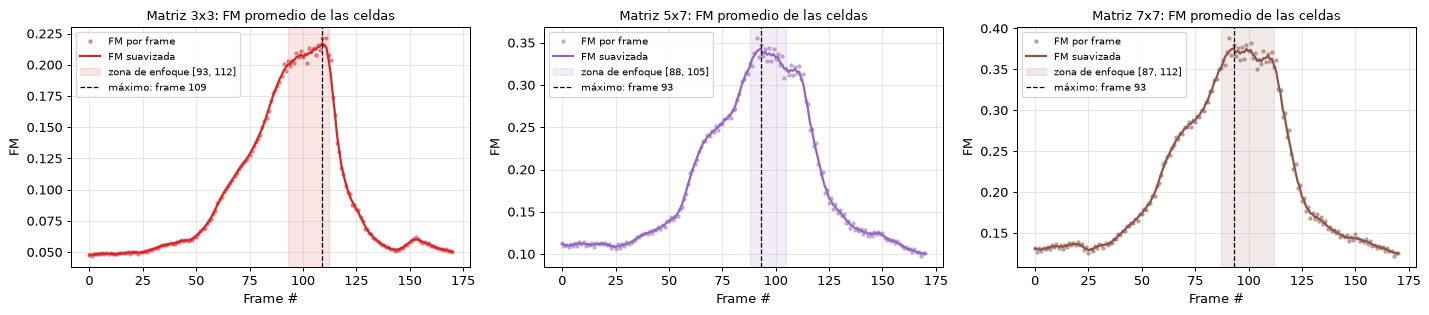

In [15]:
fig, axes = plt.subplots(1, len(CONFIGS), figsize=(16, 3.6), sharey=False)
for ax, (n, m), color in zip(axes, CONFIGS, ('C3', 'C4', 'C5')):
    r = matrices[(n, m)]
    graficar_curva(ax, r['global'], r['det'], f'Matriz {n}x{m}: FM promedio de las celdas', color)
fig.tight_layout()
plt.show()

Con la grilla 3×3 el promedio pica en el frame 109, igual que el frame completo: las nueve celdas son grandes y entre todas cubren buena parte del cuadro. Con las grillas más finas, 5×7 y 7×7, el máximo se adelanta al frame 93, lejos del 109–111 de los experimentos anteriores. Tiene explicación: cada celda mira una parte distinta de la escena, y la escena **no está a una única distancia**. Se ve claramente si dibujamos la grilla sobre el video y marcamos en verde las celdas que están enfocadas en cada momento, como los puntos de AF que se ven en el visor de una cámara.

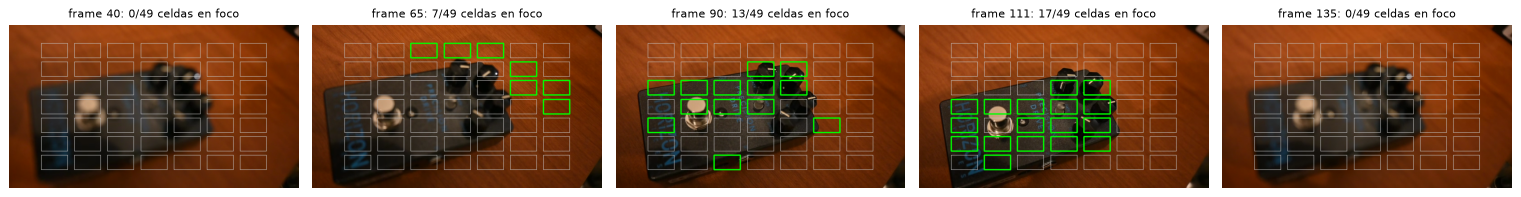

In [16]:
def celdas_enfocadas(por_celda, frame, tolerancia=0.9, ventana=5):
    # Booleano por celda: ¿su FM suavizada en 'frame' está dentro del 10 % superior de su propio rango?
    s = np.apply_along_axis(suavizar, 0, por_celda, ventana)
    umbral = s.min(axis=0) + tolerancia * (s.max(axis=0) - s.min(axis=0))
    return s[frame] >= umbral


def dibujar_matriz(img_bgr, celdas, enfocadas):
    salida = img_bgr.copy()
    for (x, y, w, h), ok in zip(celdas, enfocadas):
        color, grosor = ((0, 255, 0), 2) if ok else ((200, 200, 200), 1)
        cv.rectangle(salida, (x, y), (x + w, y + h), color, grosor)
    return salida


r77 = matrices[(7, 7)]
cuadros = (40, 65, 90, 111, 135)
fig, axes = plt.subplots(1, len(cuadros), figsize=(17, 2.4))
for ax, i in zip(axes, cuadros):
    enf = celdas_enfocadas(r77['por_celda'], i)
    mostrar(dibujar_matriz(frames_bgr[i], r77['celdas'], enf), f'frame {i}: {enf.sum()}/49 celdas en foco', ax)
fig.tight_layout()
plt.show()

El conjunto de celdas en foco se **desplaza hacia abajo** durante el barrido. Alrededor del frame 65 están enfocadas las filas superiores y la franja derecha, que corresponden a la mesa del fondo. Cerca del 90 lo están las del medio, y en el 111 las inferiores y el cuerpo del pedal. Si para cada celda nos quedamos con el frame de su propio máximo, obtenemos un mapa del frame de máximo enfoque por región. Es la base de la técnica de *shape from focus* del paper de Pertuz et al. de la carpeta `Articulos`, aunque todavía no es un mapa de profundidad: muestra qué regiones están más cerca o más lejos, pero para pasarlo a distancias reales habría que calibrar a qué distancia enfoca la lente en cada frame.

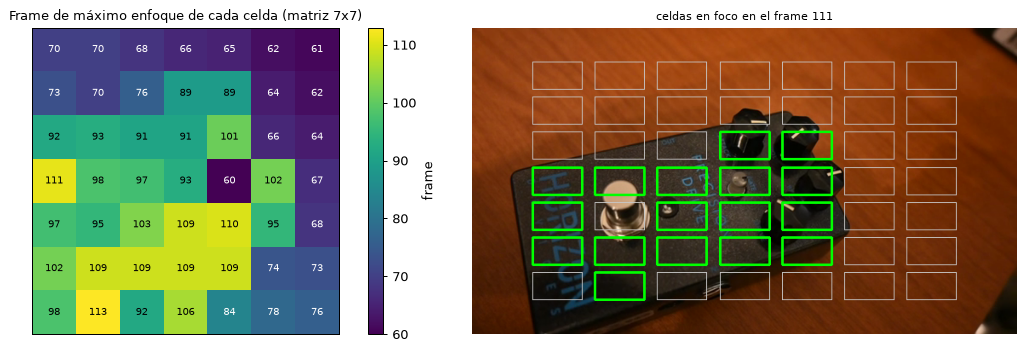

In [17]:
def mapa_frame_maximo(por_celda, n_filas, n_cols, ventana=5):
    s = np.apply_along_axis(suavizar, 0, por_celda, ventana)
    return s.argmax(axis=0).reshape(n_filas, n_cols)


mapa = mapa_frame_maximo(r77['por_celda'], 7, 7)

fig, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(14, 4))
im = ax_a.imshow(mapa, cmap='viridis')
for (i, j), v in np.ndenumerate(mapa):
    ax_a.text(j, i, str(v), ha='center', va='center', fontsize=8,
              color='w' if v < mapa.mean() else 'k')
ax_a.set_title('Frame de máximo enfoque de cada celda (matriz 7x7)', fontsize=10)
ax_a.set_xticks([]); ax_a.set_yticks([])
fig.colorbar(im, ax=ax_a, fraction=0.035, label='frame')

enf_max = celdas_enfocadas(r77['por_celda'], 111)
mostrar(dibujar_matriz(frames_bgr[111], r77['celdas'], enf_max), 'celdas en foco en el frame 111', ax_b)
fig.tight_layout()
plt.show()

El mapa tiene un gradiente claro. Las dos primeras filas alcanzan su máximo entre los frames 61 y 89, las del medio entre 91 y 111, y las inferiores, donde está el pedal, casi todas entre 98 y 113. Las dos columnas de la derecha caen casi enteras sobre la mesa, que está más lejos, y pican casi todas entre 60 y 78. Hay algunas celdas que no siguen el patrón, como el 60 en el centro. Coinciden con zonas casi sin textura, como la superficie lisa y oscura del pedal entre las perillas. Ahí la curva es casi plana, puede tener más de un máximo local, y el argmax es poco confiable.

Esto explica los resultados anteriores:

- En la medición del **frame completo**, el máximo global queda en 109 porque el pedal es el objeto con más textura y domina el conteo. La meseta ancha que vimos viene de las regiones que se enfocan antes que el pedal: la mesa y la zona del medio del cuadro.
- La **ROI central** cae sobre el pedal, así que coincide con las celdas inferiores y centrales del mapa.
- El **promedio de la grilla** le da el mismo peso a una celda sobre la mesa que a una sobre el pedal, así que termina ubicando el máximo en un punto intermedio.

Para un autofoco, "el frame de máximo enfoque" deja de ser único en cuanto la escena tiene profundidad: depende de qué se quiera enfocar. Cualquier forma de combinar las celdas en un solo número (promedio, mediana, ponderación por contraste) termina eligiendo un compromiso entre planos. Probamos también quedarnos sólo con las celdas de mayor contraste relativo, y el máximo tampoco coincide con el del pedal: se va al frame 101, porque la mesa del fondo también tiene celdas con mucho rango dinámico.

In [18]:
# ¿Y si nos quedamos sólo con las celdas de mayor contraste relativo?
rango_celdas = r77['por_celda'].max(axis=0) / r77['por_celda'].min(axis=0)
mejores = np.argsort(rango_celdas)[-12:]            # las 12 celdas (de 49) con más rango dinámico
det_mejores = detectar_maximo_enfoque(r77['por_celda'][:, mejores].mean(axis=1))

print(f"Promediando las 12 celdas de mayor rango dinámico: máximo en frame {det_mejores['frame_max']}")

Promediando las 12 celdas de mayor rango dinámico: máximo en frame 101


La matriz sí aporta el frame óptimo **por región**, algo parecido a elegir una zona de AF en una cámara (aunque muchas cámaras miden el foco por detección de fase y no por contraste): el usuario, o un detector de sujeto, decide qué celda priorizar. Por ejemplo, si elegimos como punto de AF una celda sobre el cuerpo del pedal:

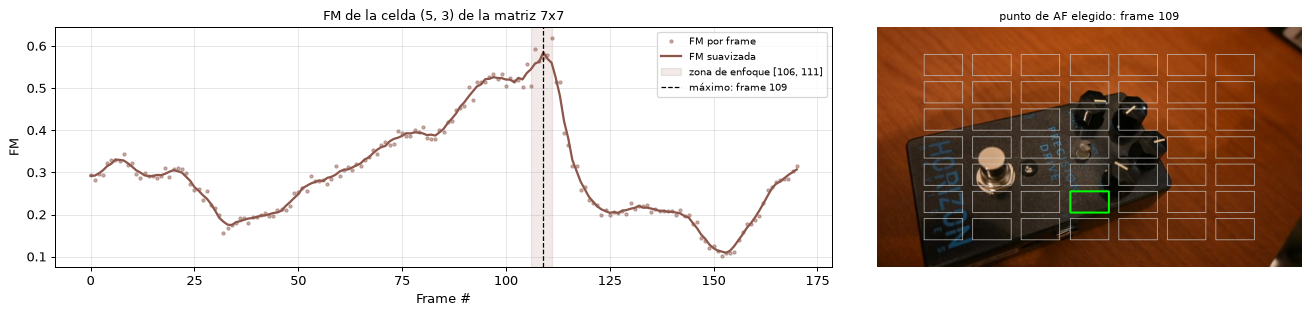

Punto de AF (5, 3): máximo en frame 109, zona [106, 111]


In [19]:
FILA_AF, COL_AF = 5, 3                  # celda de la matriz 7x7 sobre el cuerpo del pedal
idx_af = FILA_AF * 7 + COL_AF
det_af = detectar_maximo_enfoque(r77['por_celda'][:, idx_af])

fig, (ax, ax_img) = plt.subplots(1, 2, figsize=(15, 3.6), gridspec_kw={'width_ratios': [1.6, 1]})
graficar_curva(ax, r77['por_celda'][:, idx_af], det_af, f'FM de la celda ({FILA_AF}, {COL_AF}) de la matriz 7x7', 'C5')

punto_af = np.zeros(len(r77['celdas']), dtype=bool)
punto_af[idx_af] = True
mostrar(dibujar_matriz(frames_bgr[det_af['frame_max']], r77['celdas'], punto_af),
        f"punto de AF elegido: frame {det_af['frame_max']}", ax_img)
fig.tight_layout()
plt.show()

print(f"Punto de AF ({FILA_AF}, {COL_AF}): máximo en frame {det_af['frame_max']}, "
      f"zona [{det_af['inicio']}, {det_af['fin']}]")

Con un único punto de AF sobre el sujeto, la matriz vuelve a dar el frame 109, igual que el frame completo y a dos frames del 111 de la ROI central.

Sobre el tamaño de la grilla: con 3×3 las celdas son grandes (~136×76 px), la curva de cada una es suave y el mapa es grueso. Con 7×7 las celdas quedan de ~58×32 px, el mapa tiene mucha más resolución espacial, pero cada curva es más ruidosa y en las celdas sin textura el máximo es poco confiable. Es el mismo compromiso entre ventana chica y ventana grande que apareció con las ROI de 5 % y 10 %.

---
# 5. Validación con otros operadores de enfoque

Para confirmar que el máximo que encontramos no es un artefacto de la métrica espectral, comparamos con dos operadores espaciales clásicos del relevamiento de Pertuz et al. (*Analysis of focus measure operators for shape-from-focus*, en `Articulos`):

- **LAPV**: varianza del laplaciano.
- **TENG** (Tenengrad): media de la magnitud de gradiente al cuadrado, con Sobel.

Los dos miden energía de alta frecuencia, pero en el dominio espacial, sin pasar por la FFT. En el paper están definidos como sumas sobre la región; nosotros los usamos promediados por píxel, lo que sólo cambia la escala y no dónde queda el máximo.

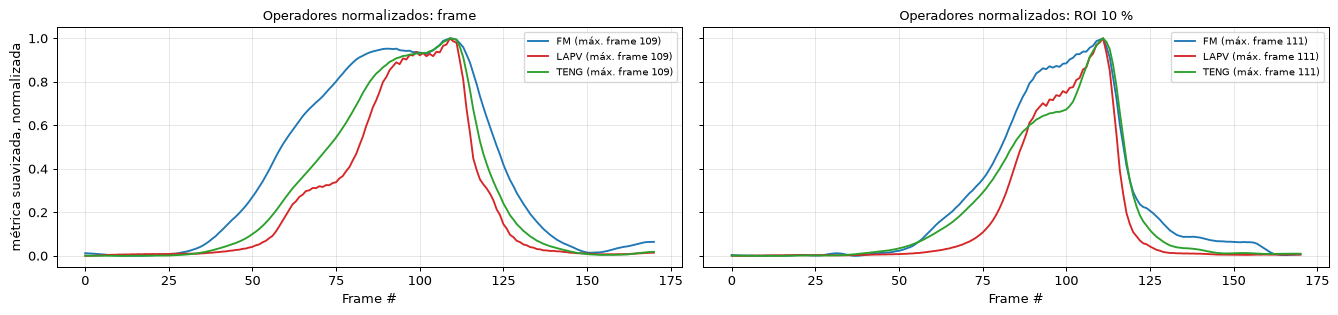

FM    frame     máximo en frame 109, zona [81, 114] (34 frames)
FM    ROI 10 %  máximo en frame 111, zona [101, 113] (13 frames)
LAPV  frame     máximo en frame 109, zona [95, 111] (17 frames)
LAPV  ROI 10 %  máximo en frame 111, zona [107, 112] (6 frames)
TENG  frame     máximo en frame 109, zona [93, 113] (21 frames)
TENG  ROI 10 %  máximo en frame 111, zona [107, 113] (7 frames)

frame     correlación FM–LAPV = 0.913,  FM–TENG = 0.969
ROI 10 %  correlación FM–LAPV = 0.967,  FM–TENG = 0.984


In [20]:
def lapv(img):
    return cv.Laplacian(img, cv.CV_64F).var()


def tenengrad(img):
    gx = cv.Sobel(img, cv.CV_64F, 1, 0, ksize=3)
    gy = cv.Sobel(img, cv.CV_64F, 0, 1, ksize=3)
    return (gx ** 2 + gy ** 2).mean()


roi10 = ROIS['ROI 10 %']
comparacion = {}
for nombre, metrica in (('FM', medida_fm), ('LAPV', lapv), ('TENG', tenengrad)):
    for region, etiqueta in ((None, 'frame'), (roi10, 'ROI 10 %')):
        curva = medir_video(frames, region, metrica)
        comparacion[(nombre, etiqueta)] = (curva, detectar_maximo_enfoque(curva))

fig, axes = plt.subplots(1, 2, figsize=(15, 3.6), sharey=True)
for ax, etiqueta in zip(axes, ('frame', 'ROI 10 %')):
    for nombre, color in zip(('FM', 'LAPV', 'TENG'), ('C0', 'C3', 'C2')):
        curva, det = comparacion[(nombre, etiqueta)]
        ax.plot(normalizar(det['suavizada']), color=color, label=f"{nombre} (máx. frame {det['frame_max']})")
    ax.set_title(f'Operadores normalizados: {etiqueta}', fontsize=10)
    ax.set_xlabel('Frame #')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
axes[0].set_ylabel('métrica suavizada, normalizada')
fig.tight_layout()
plt.show()

for (nombre, etiqueta), (_, det) in comparacion.items():
    print(f"{nombre:5s} {etiqueta:9s} máximo en frame {det['frame_max']:3d}, "
          f"zona [{det['inicio']}, {det['fin']}] ({det['fin'] - det['inicio'] + 1} frames)")
print()
for etiqueta in ('frame', 'ROI 10 %'):
    fm_c = comparacion[('FM', etiqueta)][0]
    print(f"{etiqueta:9s} correlación FM–LAPV = {np.corrcoef(fm_c, comparacion[('LAPV', etiqueta)][0])[0, 1]:.3f}"
          f",  FM–TENG = {np.corrcoef(fm_c, comparacion[('TENG', etiqueta)][0])[0, 1]:.3f}")

Los tres operadores ubican el máximo exactamente en los mismos frames, 109 sobre el frame completo y 111 sobre la ROI, y tienen correlaciones altas con FM. Una diferencia visible es que los operadores espaciales dan un pico más angosto: sus zonas de enfoque sobre el frame completo son de 17 y 21 frames, contra 34 de FM. Miden cuánta energía hay en los bordes, así que las pocas zonas muy nítidas pesan mucho. FM, en cambio, es un **conteo** de componentes que superan un umbral, y no distingue cuánto lo superan. Eso debería hacerla menos sensible a un único borde muy fuerte, a cambio de un pico menos marcado.

## 5.1 Sensibilidad al umbral

El paper fija el umbral en $\max|F| / 1000$ de forma empírica. Veamos qué pasa con otros divisores sobre el frame completo.

In [21]:
print(f'{"divisor":>8s} {"frame máx":>10s} {"max/min":>9s}')
for divisor in (100, 250, 500, 1000, 2000, 5000):
    curva = medir_video(frames, metrica=lambda im: medida_fm(im, divisor))
    det = detectar_maximo_enfoque(curva)
    print(f'{divisor:8d} {det["frame_max"]:10d} {curva.max() / curva.min():9.2f}')

 divisor  frame máx   max/min


     100         84      1.22


     250         66      1.86


     500        110      2.55


    1000        109      4.19


    2000        109      7.04


    5000        109      8.66


Con umbrales altos (divisor chico) sólo sobreviven las componentes de más baja frecuencia, que casi no dependen del foco. La métrica pierde rango dinámico y el máximo se va a cualquier lado (frames 84 y 66 con divisores 100 y 250). A partir de 500 el máximo queda en la zona correcta (109–111), y aumentar el divisor todavía más sube el contraste de la curva. El límite tiene que ser el ruido: con un divisor lo bastante grande, el umbral queda cerca del piso de ruido del sensor y de la compresión, y la métrica pasa a contar ruido. Con 5000 todavía no lo vemos, así que no sabemos dónde está ese límite para este video; nos quedamos con el 1000 del paper, que ya ubica bien el máximo.

---
# 6. Puntos extra: *unsharp masking*

El *unsharp masking* realza las altas frecuencias sumándole a la imagen una versión escalada de su componente pasaaltos:

$$g = f + k\,\big(f - G_\sigma * f\big) = (1 + k)\,f - k\,(G_\sigma * f)$$

que en OpenCV es `cv.addWeighted(f, 1 + k, blur, -k, 0)`. En el dominio de la frecuencia, el filtro equivalente es $1 + k\,(1 - \hat G_\sigma)$: vale 1 en continua y $1+k$ en alta frecuencia. Así, las componentes que el desenfoque atenuó (pero no eliminó) vuelven a superar el umbral de la métrica. Esa equivalencia vale para el filtro lineal ideal: como trabajamos con imágenes `uint8`, `addWeighted` además recorta los resultados a $[0, 255]$, y ese recorte no es lineal. Aun con pocos píxeles saturados el recorte ya baja la FM, y con $k$ grande llega a mover el máximo, como vamos a ver más abajo.

La consigna pide usarlo para **expandir la zona de enfoque**. Planteamos un criterio de aceptación fijo: un frame se considera enfocado si su FM suavizada supera el 90 % del mejor FM del video original. Después aplicamos *unsharp masking* a cada frame y vemos cuántos frames pasan a cumplir ese criterio. La función `expandir_zona_enfoque` devuelve los frames procesados y la nueva detección.

In [22]:
def unsharp_masking(img, k=1.5, sigma=2.0):
    blur = cv.GaussianBlur(img, (0, 0), sigma)
    return cv.addWeighted(img, 1 + k, blur, -k, 0)


def expandir_zona_enfoque(frames, umbral, region=None, k=1.5, sigma=2.0):
    # Aplica unsharp masking a cada frame y vuelve a detectar la zona de enfoque con un umbral absoluto.
    realzados = [unsharp_masking(f, k, sigma) for f in frames]
    curva = medir_video(realzados, region)
    return realzados, curva, detectar_maximo_enfoque(curva, umbral=umbral)


UMBRAL_ACEPTACION = 0.9 * det_frame['suavizada'].max()
det_ref = detectar_maximo_enfoque(curva_frame, umbral=UMBRAL_ACEPTACION)
frames_us, curva_us, det_us = expandir_zona_enfoque(frames, UMBRAL_ACEPTACION)

print(f"Umbral de aceptación (90 % del mejor FM original): {UMBRAL_ACEPTACION:.4f}")
print(f"Original        : zona [{det_ref['inicio']}, {det_ref['fin']}] = {det_ref['fin'] - det_ref['inicio'] + 1} frames,"
      f" máximo en {det_ref['frame_max']}")
print(f"Unsharp (k=1.5) : zona [{det_us['inicio']}, {det_us['fin']}] = {det_us['fin'] - det_us['inicio'] + 1} frames,"
      f" máximo en {det_us['frame_max']}")

Umbral de aceptación (90 % del mejor FM original): 0.0248
Original        : zona [79, 115] = 37 frames, máximo en 109
Unsharp (k=1.5) : zona [58, 124] = 67 frames, máximo en 109


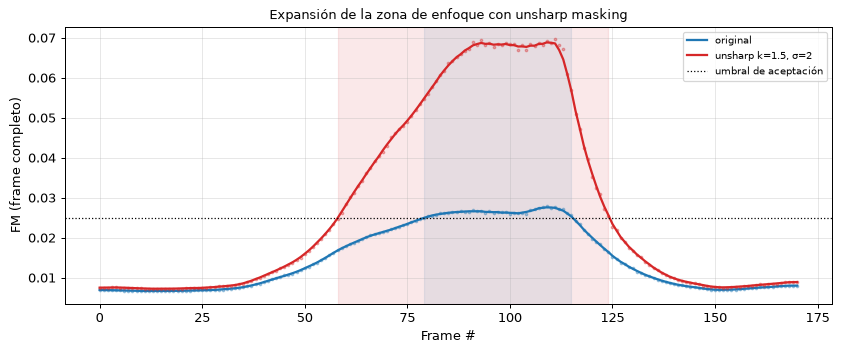

In [23]:
fig, ax = plt.subplots(figsize=(11, 4))
for curva, det, color, etiqueta in ((curva_frame, det_ref, 'C0', 'original'),
                                    (curva_us, det_us, 'C3', 'unsharp k=1.5, σ=2')):
    ax.plot(curva, '.', color=color, alpha=0.35, markersize=4)
    ax.plot(det['suavizada'], color=color, linewidth=1.8, label=etiqueta)
    ax.axvspan(det['inicio'], det['fin'], color=color, alpha=0.10)
ax.axhline(UMBRAL_ACEPTACION, color='k', linestyle=':', linewidth=1, label='umbral de aceptación')
ax.set_xlabel('Frame #')
ax.set_ylabel('FM (frame completo)')
ax.set_title('Expansión de la zona de enfoque con unsharp masking', fontsize=10)
ax.grid(alpha=0.3)
ax.legend(fontsize=8)
plt.show()

El *unsharp masking* sube toda la curva y la zona que supera el umbral de aceptación casi se duplica. Veamos cuánto depende del parámetro $k$, y comparemos también contra el criterio relativo (el 10 % superior del rango de cada curva) que usamos en los experimentos:

In [24]:
print(f'{"k":>5s} {"zona abs.":>12s} {"frames":>7s} {"zona rel.":>12s} {"frames":>7s} {"máx":>5s} {"FM frame 0":>11s}')
print(f'{"-":>5s} {str((det_ref["inicio"], det_ref["fin"])):>12s} {det_ref["fin"] - det_ref["inicio"] + 1:7d} '
      f'{str((det_frame["inicio"], det_frame["fin"])):>12s} {det_frame["fin"] - det_frame["inicio"] + 1:7d} '
      f'{det_frame["frame_max"]:5d} {curva_frame[0]:11.4f}')
for k in (0.5, 1.0, 1.5, 2.0, 4.0):
    _, curva_k, det_abs = expandir_zona_enfoque(frames, UMBRAL_ACEPTACION, k=k)
    det_rel = detectar_maximo_enfoque(curva_k)
    print(f'{k:5.1f} {str((det_abs["inicio"], det_abs["fin"])):>12s} {det_abs["fin"] - det_abs["inicio"] + 1:7d} '
          f'{str((det_rel["inicio"], det_rel["fin"])):>12s} {det_rel["fin"] - det_rel["inicio"] + 1:7d} '
          f'{det_rel["frame_max"]:5d} {curva_k[0]:11.4f}')

    k    zona abs.  frames    zona rel.  frames   máx  FM frame 0
    -    (79, 115)      37    (81, 114)      34   109      0.0070


  0.5    (66, 120)      55    (85, 113)      29   109      0.0072


  1.0    (61, 122)      62    (85, 113)      29   109      0.0073


  1.5    (58, 124)      67    (85, 113)      29   109      0.0075


  2.0    (57, 125)      69    (85, 113)      29    95      0.0078


  4.0    (52, 130)      79    (86, 113)      28    95      0.0095


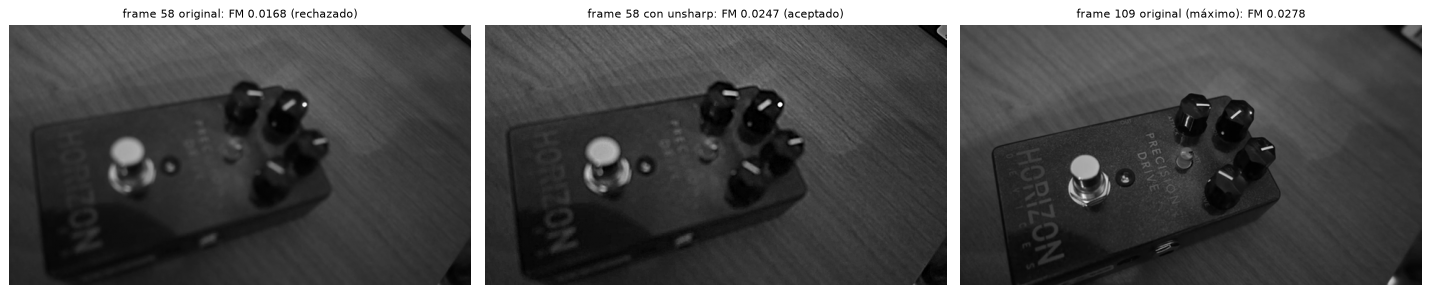

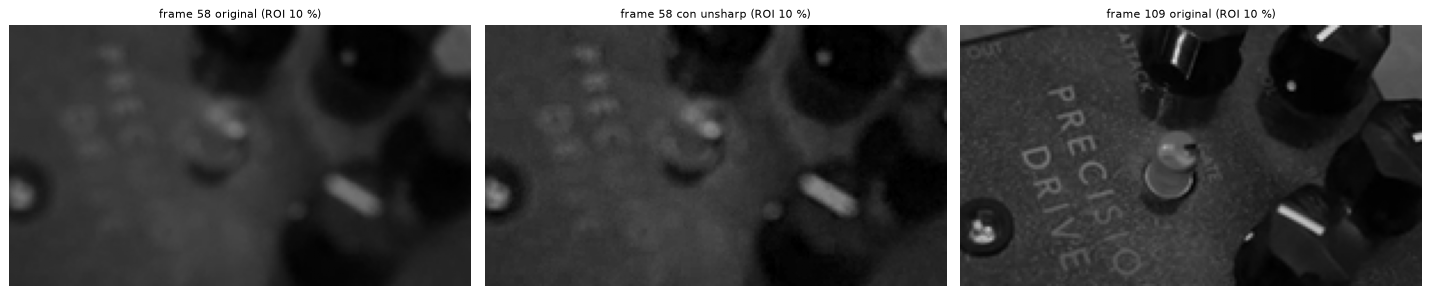

In [25]:
i_borde = det_us['inicio']
fig, axes = plt.subplots(1, 3, figsize=(16, 3.2))
mostrar(frames[i_borde], f'frame {i_borde} original: FM {curva_frame[i_borde]:.4f} (rechazado)', axes[0])
mostrar(frames_us[i_borde], f'frame {i_borde} con unsharp: FM {curva_us[i_borde]:.4f} (aceptado)', axes[1])
mostrar(frames[f_max], f'frame {f_max} original (máximo): FM {curva_frame[f_max]:.4f}', axes[2])
fig.tight_layout()
plt.show()

# Vista ampliada (ROI 10 %) para ver el efecto en los detalles
x, y, w, h = ROIS['ROI 10 %']
fig, axes = plt.subplots(1, 3, figsize=(16, 3.2))
for ax, img, t in zip(axes, (frames[i_borde], frames_us[i_borde], frames[f_max]),
                      (f'frame {i_borde} original', f'frame {i_borde} con unsharp', f'frame {f_max} original')):
    mostrar(img[y:y + h, x:x + w], t + ' (ROI 10 %)', ax)
fig.tight_layout()
plt.show()

Con el umbral absoluto, la zona de enfoque se expande en forma monótona con $k$, porque el realce lleva por encima del criterio a frames que antes quedaban afuera. Pero la vista ampliada muestra el límite: el frame 58, el primero aceptado con $k = 1.5$, gana algo de contraste en los bordes de las perillas y del LED, pero el texto del pedal sigue ilegible. Está lejos del frame 109. La métrica lo acepta, pero perceptualmente sigue desenfocado.

Hay que interpretar el resultado con cuidado:

- **El unsharp masking no recupera información.** Amplifica las altas frecuencias que el desenfoque atenuó pero no eliminó. Las que quedaron por debajo del ruido no vuelven, y lo que se amplifica en su lugar es el ruido. Por eso también sube la FM del frame 0, que está completamente desenfocado. Con $k$ grande, la métrica empieza a contar ruido realzado, y aparecen halos alrededor de los bordes.
- **Con realce moderado, el máximo no se mueve.** Hasta $k = 1.5$, el filtro realza a todos los frames de forma parecida, así que el orden entre ellos se conserva y el máximo sigue en el 109. Con el criterio relativo, la zona incluso se angosta un poco (de 34 a 29 frames). Lo que se "expande" es el conjunto de frames que superan un criterio **absoluto** de nitidez, no la forma de la curva.
- **Con realce fuerte, el detector se degrada.** Con $k \ge 2$ el máximo salta al frame 95, dentro de la meseta de la curva, donde se enfocan las regiones intermedias entre el fondo y el pedal. Pensamos primero que el realce le daba demasiado peso a la textura de la madera y al ruido, pero la causa principal es el recorte a $[0, 255]$, y lo comprobamos en la celda de abajo separando el recorte del resto del procesamiento en `uint8`.
- El efecto visual se parece al *sharpening* que aplican las cámaras al procesar la imagen, que no es parte del autofoco: se agranda la tolerancia al error de enfoque (una profundidad de campo *aparente* mayor), a cambio de ruido y halos.

In [26]:
def unsharp_float(img, k=1.5, sigma=2.0):
    # El mismo realce, en punto flotante: sin redondear ni recortar a [0, 255].
    f = img.astype(np.float64)
    return (1 + k) * f - k * cv.GaussianBlur(f, (0, 0), sigma)


# Separamos los efectos de trabajar en uint8: el recorte, el redondeo y la cadena completa de OpenCV.
variantes = {
    'float (ideal)': lambda f, k: unsharp_float(f, k),
    'sólo recorte': lambda f, k: np.clip(unsharp_float(f, k), 0, 255),
    'sólo redondeo': lambda f, k: np.round(unsharp_float(f, k)),
    'uint8 (OpenCV)': lambda f, k: unsharp_masking(f, k),
}
KS = (1.5, 2.0, 4.0)
print(f'{"variante":16s}' + ''.join(f'{"máx k=" + str(k):>11s}' for k in KS))
for nombre, realce in variantes.items():
    maximos = [detectar_maximo_enfoque(medir_video([realce(f, k) for f in frames]))['frame_max'] for k in KS]
    print(f'{nombre:16s}' + ''.join(f'{m:11d}' for m in maximos))

print()
for k in KS:
    # cuánto baja la FM sólo por el recorte, partiendo del mismo realce en punto flotante
    caidas = [100 * (1 - medida_fm(np.clip(unsharp_float(frames[n], k), 0, 255)) / medida_fm(unsharp_float(frames[n], k)))
              for n in (95, 109)]
    print(f'k = {k}: el recorte baja la FM un {caidas[0]:.0f} % en el frame 95 y un {caidas[1]:.0f} % en el 109')

variante          máx k=1.5  máx k=2.0  máx k=4.0


float (ideal)           109        109        109


sólo recorte            109         95         97


sólo redondeo           109        109        109


uint8 (OpenCV)          109         95         95

k = 1.5: el recorte baja la FM un 18 % en el frame 95 y un 20 % en el 109
k = 2.0: el recorte baja la FM un 25 % en el frame 95 y un 26 % en el 109
k = 4.0: el recorte baja la FM un 35 % en el frame 95 y un 38 % en el 109


El recorte por sí solo alcanza para sacar el máximo del 109: con $k = 2$ lo lleva al 95 y con $k = 4$ al 97. El redondeo solo no lo mueve. El frame exacto donde termina cayendo con la versión `uint8` (el 95 en los dos casos) depende además de los redondeos intermedios de OpenCV, pero lo que lo desplaza es la saturación. El recorte aplana justo los bordes de más contraste: en los frames 95 y 109 baja la FM entre un 18 % y un 38 % según $k$, y al 109, que es el más nítido, un poco más que al 95. Como en la meseta de foco los valores de esos frames son muy parecidos, esa diferencia alcanza para invertir el orden. Si el realce va a alimentar al detector, conviene hacerlo en punto flotante o mantener $k \le 1.5$.

---
## Conclusiones

**Métrica.** Implementamos la medida FM de De y Masilamani: la fracción de componentes del espectro de Fourier cuyo módulo supera $\max|F|/1000$. Verificamos que decrece monótonamente con el desenfoque gaussiano, que es invariante a la ganancia global y que el divisor de 1000 del paper es un buen punto de trabajo para este video. Con umbrales más altos la métrica pierde rango dinámico y el detector falla.

**Experimento 1 (frame completo).** La curva muestra claramente el barrido de foco y el detector ubica el máximo en el **frame 109**, pero con un pico ancho y poco contraste (máx/mín ≈ 4), porque la mesa lisa ocupa buena parte del cuadro y además se enfoca a una distancia distinta que el pedal.

**Experimento 2 (ROI central de 5 % y 10 %).** Las dos ROI ubican el máximo en el **frame 111**, con un pico mucho más angosto y el doble de contraste (máx/mín ≈ 8). Es la configuración que mejor sirve como señal de autofoco. La ROI de 5 % tiene más contraste y la de 10 % menos ruido.

**Matriz de enfoque.** Mostró el resultado más interesante del TP: como la escena está inclinada, cada celda alcanza su máximo en un frame distinto, desde ~65 en el fondo hasta ~111 sobre el pedal. El mapa de frame óptimo por celda da el orden relativo de profundidad de la escena (la base del *shape from focus*, aunque sin calibrar no son distancias) y explica tanto el pico ancho del frame completo como el máximo intermedio (frame 93) que da el promedio de las grillas finas. Con escena en profundidad no hay un único "frame de máximo enfoque": eligiendo un punto de AF sobre el pedal, la grilla vuelve a dar el frame 109.

**Validación.** Los operadores espaciales LAPV y Tenengrad coinciden con FM en la ubicación del máximo, con correlaciones de entre 0.91 y 0.98.

**Unsharp masking.** Con un criterio de nitidez absoluto (superar el 90 % del mejor FM del video original) y $k = 1.5$, casi duplica la cantidad de frames aceptados como enfocados (de 37 a 67) sin mover el máximo detectado. Esa expansión depende del criterio elegido y no es un aumento real de la profundidad de campo. Con $k \ge 2$ el máximo se desplaza, y lo que lo mueve es la saturación a $[0, 255]$ de la versión en `uint8`: sin recorte, el máximo se mantiene en el 109. El efecto es perceptual y no recupera información: amplifica lo que el desenfoque atenuó, junto con el ruido.